<a href="https://colab.research.google.com/github/Ebratul/Python/blob/main/DL/cat_vs_dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [5]:
!kaggle competitions download -c dogs-vs-cats

 97% 784M/812M [00:03<00:00, 157MB/s]
100% 812M/812M [00:03<00:00, 214MB/s]


In [6]:
import zipfile
zip_ref = zipfile.ZipFile('/content/dogs-vs-cats.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()


In [7]:
zip_ref = zipfile.ZipFile('/content/train.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [8]:
zip_ref = zipfile.ZipFile('/content/test1.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [36]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout

In [10]:
import os
import shutil

In [11]:
# Train ফোল্ডারে cats এবং dogs সাব-ফোল্ডার তৈরি
os.makedirs("/content/train/cats", exist_ok=True)
os.makedirs("/content/train/dogs", exist_ok=True)

# Test ফোল্ডারে cats এবং dogs সাব-ফোল্ডার তৈরি
os.makedirs("/content/test1/cats", exist_ok=True)
os.makedirs("/content/test1/dogs", exist_ok=True)

# Train ফোল্ডারের ইমেজগুলো ভাগ করা (prefix দিয়ে)
for file in os.listdir("/content/train"):
    if file.startswith("cat"):
        shutil.move(f"/content/train/{file}", "/content/train/cats/")
    elif file.startswith("dog"):
        shutil.move(f"/content/train/{file}", "/content/train/dogs/")

# Test ফোল্ডারের ইমেজগুলো ভাগ করা (number দিয়ে split)
for file in os.listdir("/content/test1"):
    if file.endswith(".jpg"):
        file_id = int(file.split(".")[0])  # নাম থেকে সংখ্যা বের করা
        if file_id < 12500:
            shutil.move(f"/content/test1/{file}", "/content/test1/cats/")
        else:
            shutil.move(f"/content/test1/{file}", "/content/test1/dogs/")

# চেক করা কতগুলো ইমেজ আছে
print("Train Cats:", len(os.listdir("/content/train/cats")))
print("Train Dogs:", len(os.listdir("/content/train/dogs")))
print("Test Cats:", len(os.listdir("/content/test1/cats")))
print("Test Dogs:", len(os.listdir("/content/test1/dogs")))

Train Cats: 12500
Train Dogs: 12500
Test Cats: 12499
Test Dogs: 1


In [12]:
# Dataset লোড করা
train_ds = keras.utils.image_dataset_from_directory(
    directory='/content/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory='/content/test1',
    labels='inferred',   # এখন cats/dogs ফোল্ডার আছে, তাই লেবেল ইনফার হবে
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

Found 25000 files belonging to 2 classes.
Found 12500 files belonging to 2 classes.


In [13]:
# Normalize
def process(image, label):
  image = tf.cast(image/255. ,tf.float32)
  return image, label

In [14]:
train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

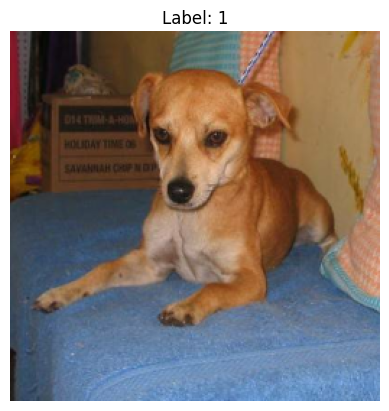

In [15]:
import matplotlib.pyplot as plt

# Dataset থেকে একটি batch নেওয়া
for images, labels in train_ds.take(1):
    # প্রথম ইমেজ দেখানো
    plt.imshow(images[0].numpy())
    plt.title(f"Label: {labels[0].numpy()}")
    plt.axis("off")
    plt.show()


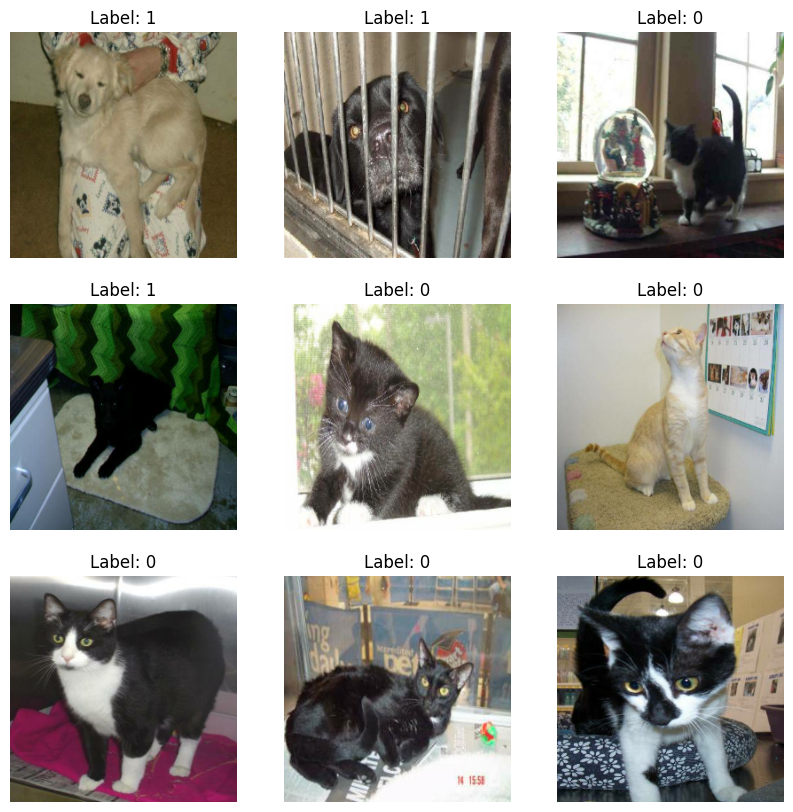

In [16]:
import matplotlib.pyplot as plt

# একটি batch থেকে 9টি ইমেজ দেখানো
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10,10))
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy())
        plt.title(f"Label: {labels[i].numpy()}")
        plt.axis("off")


In [39]:
model = Sequential()

# Convolutional Block 1
model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu', input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Convolutional Block 2
model.add(Conv2D(64, kernel_size=(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Convolutional Block 3
model.add(Conv2D(128, kernel_size=(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Flatten + Dense Layers
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Output Layer (Binary Classification: Cat vs Dog)
model.add(Dense(1, activation='sigmoid'))

# Compile Model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │    33,554,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,683,393 (128.49 MB)

 Trainable params: 33,682,177 (128.49 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [41]:
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Callbacks সেটআপ
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,          # 3 epoch ধরে উন্নতি না হলে থামবে
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath='best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,          # learning rate কমাবে
    patience=2,
    verbose=1,
    min_lr=1e-6
)

# Model Training
history = model.fit(
    train_ds,
    epochs=20,                    # epoch সংখ্যা বাড়ানো হলো
    validation_data=validation_ds,
    callbacks=[early_stop, checkpoint, reduce_lr]
)


Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5919 - loss: 0.8067
Epoch 1: val_loss improved from inf to 1.02636, saving model to best_model.h5


782/782 ━━━━━━━━━━━━━━━━━━━━ 117s 131ms/step - accuracy: 0.5919 - loss: 0.8066 - val_accuracy: 0.5079 - val_loss: 1.0264 - learning_rate: 0.0010
Epoch 2/20
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.7063 - loss: 0.5613
Epoch 2: val_loss did not improve from 1.02636
782/782 ━━━━━━━━━━━━━━━━━━━━ 86s 109ms/step - accuracy: 0.7064 - loss: 0.5613 - val_accuracy: 0.4142 - val_loss: 1.1645 - learning_rate: 0.0010
Epoch 3/20
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.7533 - loss: 0.4979
Epoch 3: val_loss improved from 1.02636 to 1.01483, saving model to best_model.h5


782/782 ━━━━━━━━━━━━━━━━━━━━ 87s 111ms/step - accuracy: 0.7533 - loss: 0.4979 - val_accuracy: 0.4551 - val_loss: 1.0148 - learning_rate: 0.0010
Epoch 4/20
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.7995 - loss: 0.4298
Epoch 4: val_loss did not improve from 1.01483
782/782 ━━━━━━━━━━━━━━━━━━━━ 85s 109ms/step - accuracy: 0.7995 - loss: 0.4298 - val_accuracy: 0.4198 - val_loss: 1.5021 - learning_rate: 0.0010
Epoch 5/20
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.8288 - loss: 0.3828
Epoch 5: val_loss improved from 1.01483 to 0.78476, saving model to best_model.h5


782/782 ━━━━━━━━━━━━━━━━━━━━ 97s 124ms/step - accuracy: 0.8288 - loss: 0.3827 - val_accuracy: 0.6968 - val_loss: 0.7848 - learning_rate: 0.0010
Epoch 6/20
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.8601 - loss: 0.3222
Epoch 6: val_loss did not improve from 0.78476
782/782 ━━━━━━━━━━━━━━━━━━━━ 85s 109ms/step - accuracy: 0.8601 - loss: 0.3221 - val_accuracy: 0.5996 - val_loss: 1.0931 - learning_rate: 0.0010
Epoch 7/20
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.8705 - loss: 0.3054
Epoch 7: val_loss did not improve from 0.78476

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 108ms/step - accuracy: 0.8705 - loss: 0.3055 - val_accuracy: 0.5498 - val_loss: 1.3034 - learning_rate: 0.0010
Epoch 8/20
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9014 - loss: 0.2408
Epoch 8: val_loss did not improve from 0.78476
782/782 ━━━━━━━━━━━━━━━━━━━━ 85s 109ms/step - accuracy: 0.9014 - loss: 0.2407 - val_acc

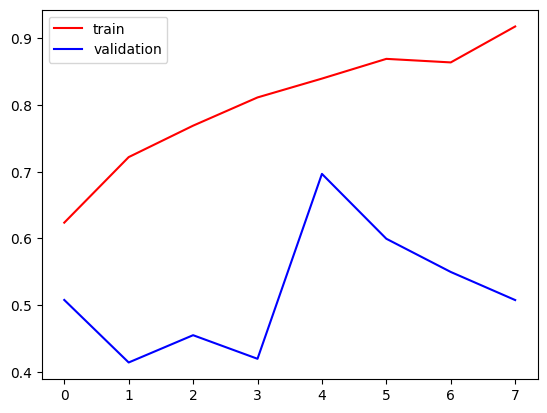

In [44]:
plt.plot(history.history['accuracy'], color = 'red', label = 'train')
plt.plot(history.history['val_accuracy'], color = 'blue', label = 'validation')
plt.legend()
plt.show()

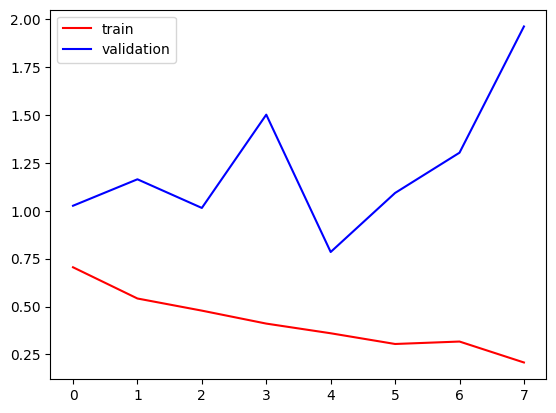

In [45]:
plt.plot(history.history['loss'], color = 'red', label = 'train')
plt.plot(history.history['val_loss'], color = 'blue', label = 'validation')
plt.legend()
plt.show()

In [50]:
import tensorflow as tf
import numpy as np
import cv2

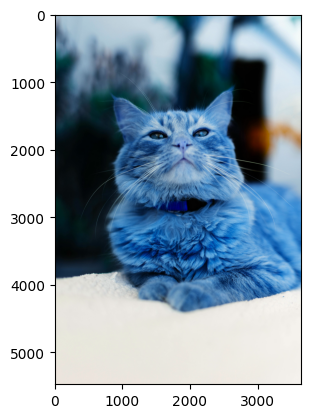

In [72]:
# ইমেজ লোড করা
test_path = "/content/cat.jpg"
test_img = cv2.imread(test_path)
plt.imshow(test_img)

In [73]:
test_img.shape

(5472, 3648, 3)

In [74]:
test_img = cv2.resize(test_img, (256, 256))
test_img = test_img.reshape(1, 256, 256, 3)
model.predict(test_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([[1.]], dtype=float32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


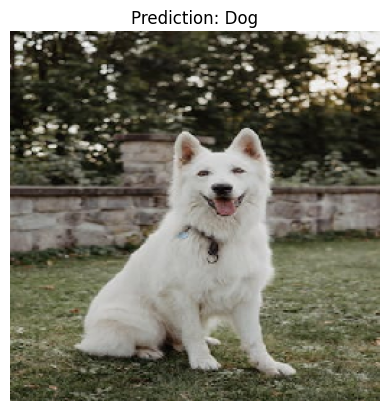

Raw prediction value: 0.9782842


In [68]:

img = tf.keras.utils.load_img(test_path, target_size=(256, 256))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)   # batch dimension যোগ করা
img_array = img_array / 255.0                   # normalize করা

# Prediction
prediction = model.predict(img_array)

# ফলাফল দেখানো
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {'Dog' if prediction[0][0] > 0.5 else 'Cat'}")
plt.show()

print("Raw prediction value:", prediction[0][0])